# Dataset Understanding and EDA

## Project objective

This notebook keeps EDA focused on what the project brief requires: checking whether the selected dataset supports a Deep Learning image-classification proof of concept and identifying modelling risks that affect interpretation.

The Mendeley Data record documents the broader acquisition context and target classes. The analysis verifies the local data, examines representative examples and connects the findings to preprocessing, splitting and evaluation decisions.

In [20]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

DATA_DIR = Path("../data/raw/GVLiD")
CLASS_NAMES = [
    "Black rot",
    "esca",
    "healthy",
    "leaf blight",
]

np.random.seed(RANDOM_SEED)

# Confirm that the local dataset directory is available
print("Dataset path:", DATA_DIR)
print("Dataset directory exists:", DATA_DIR.exists())

Dataset path: ../data/raw/GVLiD
Dataset directory exists: True


## Dataset loading

The dataset is loaded from the local raw-data directory to confirm that it is available and that the class folders correspond to the four target labels defined for the image-classification task.

In [2]:
# Identify the class folders available in the local dataset
class_folders = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir() and folder.name != "docs"
])

print("Class folders found:", class_folders)
print("Number of classes:", len(class_folders))

# Check whether the local folders match the expected target classes
print("Expected classes:", sorted(CLASS_NAMES))
print("Class folders match expected classes:", class_folders == sorted(CLASS_NAMES))

Class folders found: ['Black rot', 'esca', 'healthy', 'leaf blight']
Number of classes: 4
Expected classes: ['Black rot', 'esca', 'healthy', 'leaf blight']
Class folders match expected classes: True


### Conclusion

The local dataset was successfully loaded and contains the four expected target classes: **Black rot, Esca, Healthy, and Leaf blight**. The folder structure matches the target labels defined for the project, confirming that the dataset is correctly organised for a supervised multiclass image-classification task.

## Dataset structure

The dataset structure is examined to verify the class folders, image file formats and integrity of the raw data before further analysis.

In [3]:
# Inspect the number and format of image files in each class folder
image_extensions = {".jpg", ".jpeg", ".png"}

structure_summary = []

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name
    
    all_files = [f for f in class_dir.iterdir() if f.is_file()]
    image_files = [f for f in all_files if f.suffix.lower() in image_extensions]
    non_image_files = [f for f in all_files if f.suffix.lower() not in image_extensions]
    
    structure_summary.append({
        "Class": class_name,
        "Total files": len(all_files),
        "Image files": len(image_files),
        "Non-image files": len(non_image_files)
    })

structure_df = pd.DataFrame(structure_summary)

print("Dataset structure:")
display(structure_df)

print("\nTotal image files:", structure_df["Image files"].sum())

Dataset structure:


,Class,Total files,Image files,Non-image files
0,Black rot,808,808,0
1,esca,888,888,0
2,healthy,1109,1109,0
3,leaf blight,672,672,0



Total image files: 3477


### Conclusion

The dataset contains **3,477 image files** distributed across four class folders:

- Black rot: 808 images
- Esca: 888 images
- Healthy: 1,109 images
- Leaf blight: 672 images

All files contained in the class folders are recognised image files, with no unexpected non-image files identified. The raw dataset remains organised by class and has not been modified at this stage.

## Class distribution

The distribution of images across the four target classes is analysed to identify potential class imbalance that may affect model training and evaluation.

,Class,Image files,Percentage
0,Black rot,808,23.24
1,esca,888,25.54
2,healthy,1109,31.90
3,leaf blight,672,19.33


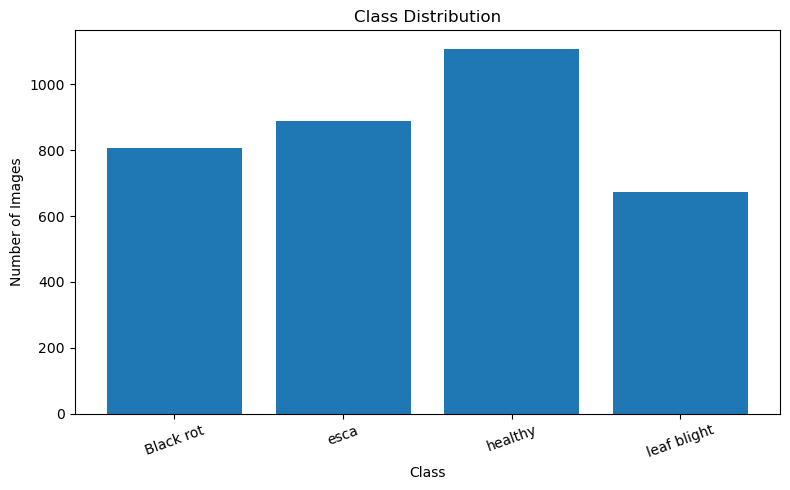

In [4]:
# Calculate the class distribution
class_distribution = structure_df[["Class", "Image files"]].copy()

total_images = class_distribution["Image files"].sum()

class_distribution["Percentage"] = (
    class_distribution["Image files"] / total_images * 100
).round(2)

display(class_distribution)

# Visualise the number of images in each class
plt.figure(figsize=(8, 5))
plt.bar(
    class_distribution["Class"],
    class_distribution["Image files"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Conclusion

The dataset shows a **moderate class imbalance**. Healthy is the most represented class (31.90%), while Leaf blight is the least represented (19.33%). Esca (25.54%) and Black rot (23.24%) fall between these two.

The imbalance is not severe, but it should be considered during model evaluation. Overall accuracy alone may hide differences in performance between classes. Therefore, class-level performance and the confusion matrix should also be examined during the evaluation stage.

## Image dimensions

The image dimensions and colour mode are examined to assess their consistency across the dataset and identify preprocessing requirements for the CNN modelling stage.

In [6]:
# Inspect image dimensions and colour mode across the full dataset
image_properties = []

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_properties.append({
                "Class": class_name,
                "Width": img.width,
                "Height": img.height,
                "Mode": img.mode
            })

image_properties_df = pd.DataFrame(image_properties)

print("Number of images inspected:", len(image_properties_df))

print("\nImage dimensions:")
display(
    image_properties_df[["Width", "Height"]]
    .value_counts()
    .reset_index(name="Count")
)

print("\nImage colour modes:")
display(
    image_properties_df["Mode"]
    .value_counts()
    .reset_index(name="Count")
)

Number of images inspected: 3477

Image dimensions:


,Width,Height,Count
0,1080,1080,3477



Image colour modes:


,Mode,Count
0,RGB,3477


### Conclusion

All **3,477 images** were inspected and have consistent dimensions of **1080 × 1080 pixels** and **RGB colour mode**.

This consistency simplifies the preprocessing pipeline because there are no differences in image dimensions or colour channels that need to be corrected. However, the original 1080 × 1080 resolution is relatively large for CNN training. The images should therefore be resized to the input dimensions selected for the CNN during the modelling stage, balancing computational efficiency with preservation of relevant visual information.

## Example images by class

Representative images from each class are visually examined to assess variability in lighting, background, orientation, scale and symptom appearance, as well as potential visual similarities between disease classes.

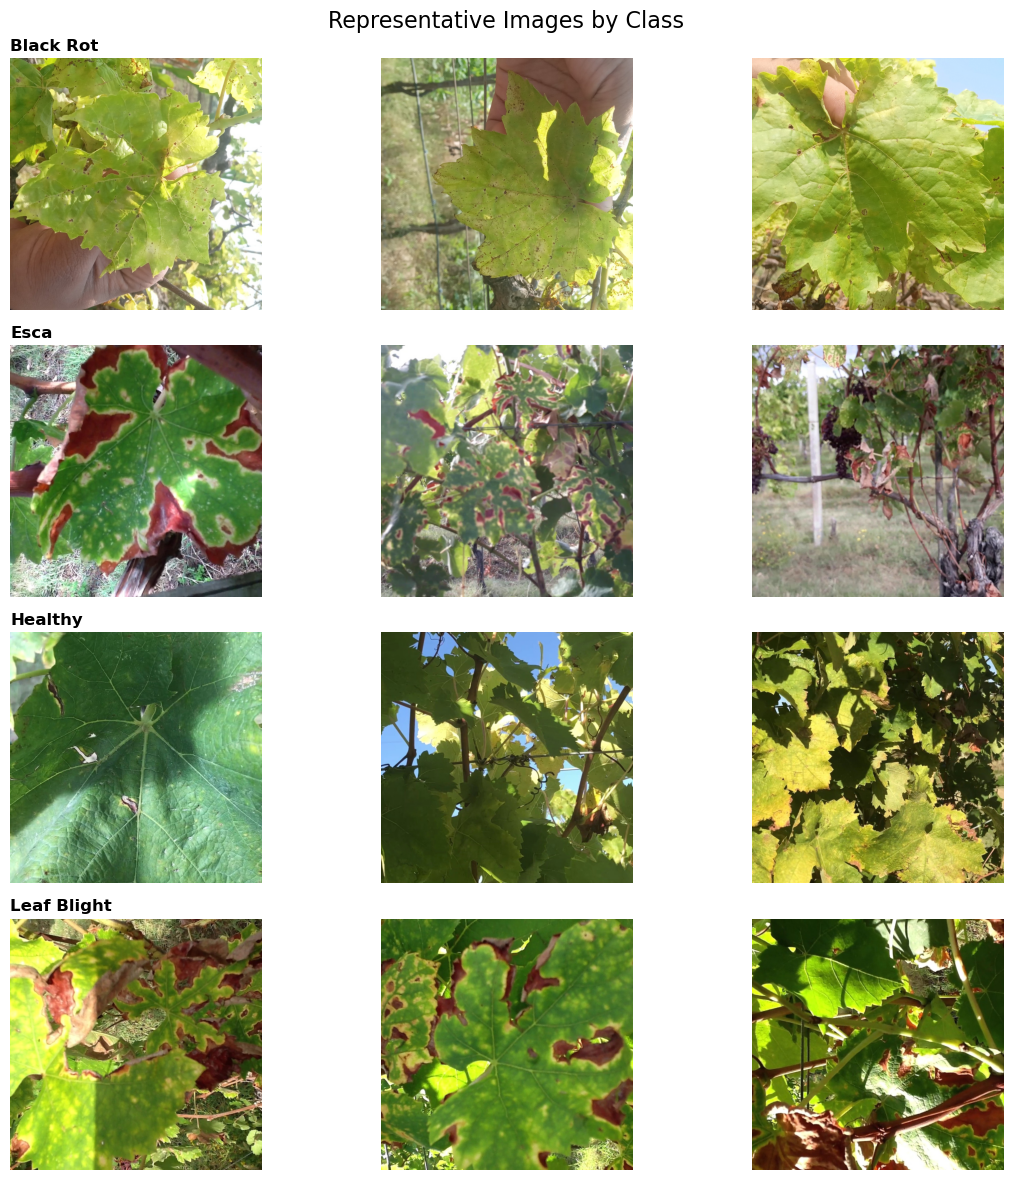

In [8]:
# Display representative random images from each class
n_samples = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    n_samples,
    figsize=(12, 12)
)

for row, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / class_name
    image_files = sorted(class_dir.glob("*.jpg"))

    selected_images = np.random.choice(
        image_files,
        size=n_samples,
        replace=False
    )

    for col, image_path in enumerate(selected_images):
        with Image.open(image_path) as img:
            axes[row, col].imshow(img)

        axes[row, col].axis("off")

        # Display the class name above the first image in each row
        if col == 0:
            axes[row, col].set_title(
                class_name.title(),
                fontsize=12,
                fontweight="bold",
                loc="left"
            )

plt.suptitle(
    "Representative Images by Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Conclusion

The visual inspection shows substantial real-world variability in the dataset. Images differ in **leaf orientation, scale, lighting and background**, ranging from close-up views of individual leaves to wider vineyard scenes. Backgrounds may include other leaves, branches, soil, sky, vineyard structures and hands.

Disease symptoms also vary in appearance and extent, while some classes show potentially similar visual patterns, such as brown or necrotic areas. These characteristics make the classification task more challenging but also more representative of field conditions.

The model should therefore learn relevant visual features from the leaves and disease symptoms rather than relying on consistent backgrounds or image composition.

## Data quality checks

Basic data quality checks are performed to identify unreadable images, unexpected file formats and duplicate filenames that could affect subsequent preprocessing or modelling.

In [9]:
# Perform basic data quality checks
unreadable_files = []
unexpected_formats = []
all_filenames = []

valid_extensions = {".jpg", ".jpeg", ".png"}

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    for file_path in class_dir.iterdir():
        if not file_path.is_file():
            continue

        all_filenames.append(file_path.name)

        # Check file format
        if file_path.suffix.lower() not in valid_extensions:
            unexpected_formats.append(str(file_path))
            continue

        # Check whether the image can be opened correctly
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            unreadable_files.append(str(file_path))

# Check for repeated filenames across the dataset
filename_counts = pd.Series(all_filenames).value_counts()
duplicate_filenames = filename_counts[filename_counts > 1]

print("Total files checked:", len(all_filenames))
print("Unreadable image files:", len(unreadable_files))
print("Unexpected file formats:", len(unexpected_formats))
print("Duplicate filenames:", len(duplicate_filenames))

Total files checked: 3477
Unreadable image files: 0
Unexpected file formats: 0
Duplicate filenames: 0


### Conclusion

The basic data quality checks identified **no unreadable images, unexpected file formats or duplicate filenames** among the 3,477 image files.

This indicates that the dataset is technically consistent and ready for subsequent preprocessing and modelling. These checks do not, however, test for visually identical or near-duplicate images.

## Train / validation / test split

The available metadata is examined before defining the train, validation and test sets to identify potential relationships between images that should be considered when selecting a reproducible splitting strategy.

In [12]:
# Inspect the metadata structure before defining the train/validation/test split
metadata_path = DATA_DIR / "metadata.json"

with open(metadata_path, "r", encoding="utf-8") as file:
    metadata = json.load(file)

print("Metadata object type:", type(metadata).__name__)

if isinstance(metadata, dict):
    print("Top-level keys:", list(metadata.keys()))
elif isinstance(metadata, list):
    print("Number of metadata records:", len(metadata))
    if len(metadata) > 0:
        print("Fields in first record:", list(metadata[0].keys()))

Metadata object type: list
Number of metadata records: 3477
Fields in first record: ['Image_ID', 'image_filename', 'Location', 'Environmental_Conditions', 'Plant_Health_Status', 'Disease_Type', 'Device_Specifications']


In [14]:
# Convert metadata to a DataFrame for inspection
metadata_df = pd.DataFrame(metadata)

print("Metadata shape:", metadata_df.shape)

print("\nFirst 5 metadata records:")
display(metadata_df.head())

print("\nColumn data types:")
display(metadata_df.dtypes)

print("\nSample values from each metadata field:")
for column in metadata_df.columns:
    print(f"\n{column}:")
    print(metadata_df[column].head(3).tolist())

Metadata shape: (3477, 7)

First 5 metadata records:


,Image_ID,image_filename,Location,Environmental_Conditions,Plant_Health_Status,Disease_Type,Device_Specifications
0,IMG_0001,black rot001.jpg,"{'Vineyard': 'Vineyard_22', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T15:13:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
1,IMG_0002,black rot002.jpg,"{'Vineyard': 'Vineyard_28', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T12:58:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
2,IMG_0003,black rot003.jpg,"{'Vineyard': 'Vineyard_14', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T12:36:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
3,IMG_0004,black rot004.jpg,"{'Vineyard': 'Vineyard_20', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T08:40:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
4,IMG_0005,black rot005.jpg,"{'Vineyard': 'Vineyard_8', 'GPS': {'Latitude':...",{'Time_of_Capture': '2023-06-15T18:02:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."



Column data types:


Image_ID                       str
image_filename                 str
Location                    object
Environmental_Conditions    object
Plant_Health_Status            str
Disease_Type                   str
Device_Specifications       object
dtype: object


Sample values from each metadata field:

Image_ID:
['IMG_0001', 'IMG_0002', 'IMG_0003']

image_filename:
['black rot001.jpg', 'black rot002.jpg', 'black rot003.jpg']

Location:
[{'Vineyard': 'Vineyard_22', 'GPS': {'Latitude': 18.785238, 'Longitude': 73.994949}}, {'Vineyard': 'Vineyard_28', 'GPS': {'Latitude': 18.731029, 'Longitude': 73.977206}}, {'Vineyard': 'Vineyard_14', 'GPS': {'Latitude': 18.802297, 'Longitude': 74.027516}}]

Environmental_Conditions:
[{'Time_of_Capture': '2023-06-15T15:13:00+05:30', 'Lighting': 'Overcast', 'Weather': 'Humid'}, {'Time_of_Capture': '2023-06-15T12:58:00+05:30', 'Lighting': 'Natural sunlight', 'Weather': 'Humid'}, {'Time_of_Capture': '2023-06-15T12:36:00+05:30', 'Lighting': 'Partly cloudy', 'Weather': 'Humid'}]

Plant_Health_Status:
['Diseased', 'Diseased', 'Diseased']

Disease_Type:
['Black Rot', 'Black Rot', 'Black Rot']

Device_Specifications:
[{'Device_Name': 'Redmi Note 10 5G', 'Sensor': 'Sony IMX 582 1/2rr', 'OS': 'Android'}, {'Device_Name': 'R

### Metadata inspection

The metadata contains **3,477 records**, corresponding to the 3,477 images in the dataset. Each image is associated with a unique image identifier and filename, as well as additional information about **location, environmental conditions, plant health status, disease type and image-capture device**.

The `Location` field includes both a **vineyard identifier and GPS coordinates**, while the environmental metadata includes the **time of capture, lighting and weather conditions**. This information is relevant when defining the train, validation and test sets because images captured in the same vineyard or under closely related conditions may share characteristics beyond the disease symptoms.

Therefore, the metadata should be examined further before selecting the splitting strategy, in order to reduce the risk of data leakage and obtain a more realistic evaluation of model generalisation.

### Vineyard analysis

Before defining the train, validation and test split, the distribution of images across vineyards was examined to determine whether vineyard location could be used as a meaningful grouping variable.

If images from the same vineyard are distributed across training and evaluation subsets, the model may learn location-specific characteristics such as background, vegetation or environmental conditions rather than relying only on disease-related visual patterns. Examining the distribution of disease classes across vineyards therefore helps assess whether a vineyard-based split could provide a more robust evaluation of model generalisation.

In [15]:
# Extract vineyard information from the nested metadata
metadata_df["Vineyard"] = metadata_df["Location"].apply(
    lambda x: x.get("Vineyard") if isinstance(x, dict) else None
)

print("Number of unique vineyards:", metadata_df["Vineyard"].nunique())

print("\nImages per vineyard:")
display(
    metadata_df["Vineyard"]
    .value_counts()
    .sort_index()
)

print("\nDisease classes per vineyard:")
vineyard_class_table = pd.crosstab(
    metadata_df["Vineyard"],
    metadata_df["Disease_Type"]
)

display(vineyard_class_table)

Number of unique vineyards: 28

Images per vineyard:


Vineyard
Vineyard_1     109
Vineyard_10    125
Vineyard_11    133
Vineyard_12    134
Vineyard_13    117
Vineyard_14    117
Vineyard_15    125
Vineyard_16    109
Vineyard_17    123
Vineyard_18    122
Vineyard_19    112
Vineyard_2     122
Vineyard_20    108
Vineyard_21    120
Vineyard_22    130
Vineyard_23    135
Vineyard_24    144
Vineyard_25    134
Vineyard_26    142
Vineyard_27    125
Vineyard_28    124
Vineyard_3     123
Vineyard_4     126
Vineyard_5     127
Vineyard_6     129
Vineyard_7     107
Vineyard_8     130
Vineyard_9     125
Name: count, dtype: int64


Disease classes per vineyard:


Disease_Type,Black Rot,Esca,Healthy,Leaf Blight
Vineyard,,,,
Vineyard_1,14,34,38,23
Vineyard_10,34,37,34,20
Vineyard_11,29,41,40,23
Vineyard_12,33,33,41,27
Vineyard_13,26,29,41,21
Vineyard_14,30,30,35,22
Vineyard_15,21,30,35,39
Vineyard_16,18,27,44,20
Vineyard_17,32,31,35,25


### Conclusion

The dataset contains **28 vineyards**, and all four target classes are represented across the vineyards. This indicates that disease labels are not restricted to specific vineyard locations.

The vineyard information provides a potential grouping variable for the train, validation and test split. Keeping images from the same vineyard within the same subset could reduce the risk of location-specific characteristics being shared between training and evaluation data and would provide a stronger test of model generalisation to unseen vineyards.

However, the final splitting strategy should also consider the distribution of images and classes across the resulting subsets to ensure that all four classes remain adequately represented.

### Capture date analysis

Before defining the train, validation and test split, the capture timestamps were examined to determine whether the dataset contains distinct acquisition dates that could represent separate data collection sessions.

Images captured during the same acquisition period may share environmental or contextual characteristics. Identifying independent capture dates could therefore provide an additional grouping variable and help reduce the risk of closely related images being distributed across training and evaluation subsets.

In [16]:
# Extract capture time from the environmental metadata
metadata_df["Time_of_Capture"] = metadata_df["Environmental_Conditions"].apply(
    lambda x: x.get("Time_of_Capture") if isinstance(x, dict) else None
)

metadata_df["Time_of_Capture"] = pd.to_datetime(
    metadata_df["Time_of_Capture"],
    errors="coerce"
)

metadata_df["Capture_Date"] = metadata_df["Time_of_Capture"].dt.date

print("Missing capture timestamps:", metadata_df["Time_of_Capture"].isna().sum())
print("Number of unique capture dates:", metadata_df["Capture_Date"].nunique())

print("\nCapture date range:")
print("First date:", metadata_df["Capture_Date"].min())
print("Last date:", metadata_df["Capture_Date"].max())

print("\nImages per capture date:")
display(
    metadata_df["Capture_Date"]
    .value_counts()
    .sort_index()
)

Missing capture timestamps: 0
Number of unique capture dates: 1

Capture date range:
First date: 2023-06-15
Last date: 2023-06-15

Images per capture date:


Capture_Date
2023-06-15    3477
Name: count, dtype: int64

### Conclusion

All **3,477 images** contain valid capture timestamps and were recorded on the same date, **15 June 2023**.

Therefore, capture date does not provide an independent grouping variable for the train, validation and test split. Although capture times vary throughout the day, the available metadata does not establish distinct acquisition sessions that could be reliably used for grouping.

The vineyard identifier remains the most meaningful available variable for controlling location-related overlap between the training and evaluation subsets.

### Splitting strategy

Based on the metadata analysis, the **vineyard identifier** was selected as the grouping variable for the train, validation and test split.

A vineyard-based split keeps all images from the same vineyard within the same subset. This reduces the risk that location-specific characteristics are shared between training and evaluation data and provides a more realistic assessment of the model's ability to generalise to unseen vineyards.

The split should also preserve adequate representation of all four disease classes across the training, validation and test subsets. A reproducible random seed will be used so that the same split can be applied consistently throughout the project.

Given the 28 available vineyards, the target allocation is **20 vineyards for training, 4 for validation and 4 for testing**, corresponding approximately to a 70/15/15 split. The resulting class distributions will be checked before the split is adopted for modelling.

In [17]:
# Create a reproducible vineyard-based train/validation/test split

vineyards = sorted(metadata_df["Vineyard"].unique())

rng = np.random.default_rng(RANDOM_SEED)
shuffled_vineyards = rng.permutation(vineyards)

train_vineyards = shuffled_vineyards[:20]
val_vineyards = shuffled_vineyards[20:24]
test_vineyards = shuffled_vineyards[24:28]

# Assign each image according to its vineyard
def assign_split(vineyard):
    if vineyard in train_vineyards:
        return "Train"
    elif vineyard in val_vineyards:
        return "Validation"
    else:
        return "Test"

metadata_df["Split"] = metadata_df["Vineyard"].apply(assign_split)

print("Vineyards per split:")
print(metadata_df.groupby("Split")["Vineyard"].nunique())

print("\nImages per split:")
split_counts = metadata_df["Split"].value_counts()
split_percentages = (
    split_counts / len(metadata_df) * 100
).round(2)

display(
    pd.DataFrame({
        "Images": split_counts,
        "Percentage": split_percentages
    })
)

print("\nDisease classes per split:")
split_class_table = pd.crosstab(
    metadata_df["Split"],
    metadata_df["Disease_Type"]
)

display(split_class_table)

Vineyards per split:
Split
Test           4
Train         20
Validation     4
Name: Vineyard, dtype: int64

Images per split:


,Images,Percentage
Split,,
Train,2492,71.67
Validation,510,14.67
Test,475,13.66



Disease classes per split:


Disease_Type,Black Rot,Esca,Healthy,Leaf Blight
Split,,,,
Test,120,124,144,87
Train,560,631,807,494
Validation,129,133,158,90


### Split validation

The vineyard-based split resulted in **20 vineyards for training, 4 for validation and 4 for testing**. This corresponds to **2,492 training images (71.67%)**, **510 validation images (14.67%)** and **475 test images (13.66%)**, closely matching the intended 70/15/15 allocation.

All four target classes are represented in each subset, and the overall class distribution remains reasonably consistent across training, validation and test data. Healthy remains the most represented class and Leaf Blight the least represented class in all three subsets.

The resulting split is therefore suitable for the modelling stage while maintaining separation between vineyards and providing independent vineyard groups for validation and final testing.

### Saving the dataset split

To ensure that the same train, validation and test allocation can be used consistently during the modelling and evaluation stages, the split assignment for each image is saved in a separate file.

The file records the image identifier, filename, vineyard, disease class and assigned subset. This prevents the dataset from being randomly split again during modelling and ensures that all subsequent experiments use the same vineyard-based partition.

In [18]:
# Save the reproducible split for use in the modelling stage

split_df = metadata_df[
    ["Image_ID", "image_filename", "Vineyard", "Disease_Type", "Split"]
].copy()

split_output_path = PROJECT_ROOT / "data" / "processed" / "dataset_split.csv"

split_df.to_csv(
    split_output_path,
    index=False
)

print("Split file saved to:", split_output_path)
print("Number of records saved:", len(split_df))


Split file saved to: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/processed/dataset_split.csv
Number of records saved: 3477


### Conclusion

The vineyard-based split was successfully saved for all **3,477 images**. This file provides a consistent train, validation and test allocation that can be reused during the modelling and evaluation stages without redefining the dataset split.

## Preprocessing summary



### Recommended preprocessing requirements

Based on the dataset analysis, the CNN modelling pipeline should apply the following preprocessing consistently across the dataset:

- **Image resizing:** all original images are 1080 × 1080 pixels. They should be resized to the input dimensions selected for the CNN architecture in the modelling stage.
- **Pixel normalisation:** RGB pixel values should be scaled to a consistent numerical range before being provided to the neural network, using the preprocessing approach selected for the CNN architecture.
- **Label encoding:** the four target classes — Black Rot, Esca, Healthy and Leaf Blight — must be encoded consistently for multiclass classification.
- **Dataset split:** the vineyard-based train, validation and test allocation defined in `dataset_split.csv` should be preserved throughout modelling and evaluation.
- **Data augmentation:** augmentation may be considered for the training set to improve robustness to the observed variation in orientation, scale and image conditions. Any augmentation strategy should be defined and applied only during the modelling stage.

## EDA conclusions


The EDA indicates that the **GVLiD dataset provides a suitable basis for the proposed grapevine disease image-classification proof of concept**. It contains 3,477 RGB grapevine leaf images across four target classes — Black Rot, Esca, Healthy and Leaf Blight — with consistent image dimensions and no unreadable files, unexpected formats or duplicate filenames identified during the basic quality checks.

The dataset also presents characteristics that make the classification problem representative of real-world field conditions. Images vary in orientation, scale, lighting and background, while disease symptoms differ in appearance and extent and may show visual similarities across classes. The moderate class imbalance should also be considered when evaluating model performance.

The metadata analysis identified 28 vineyards, with all four target classes represented across them. A vineyard-based train, validation and test split was therefore defined to reduce location-related overlap between training and evaluation data and provide a stronger assessment of generalisation to unseen vineyards.

The resulting model should be interpreted as a **decision-support proof of concept rather than an autonomous diagnostic system**. Its predictions could help vineyard managers or agronomists prioritise leaves or vineyard areas for further human inspection, while final disease assessment remains subject to expert validation.